<a href="https://colab.research.google.com/github/seunghyun949-dot/wafer-map-defect-classification/blob/main/notebooks/01_wafer_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Pandas: 2.2.3
NumPy: 2.1.3
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

PROJECT_DIR = Path("/content/drive/MyDrive/wafer_map_project")
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_DIR)

Mounted at /content/drive
/content/drive/MyDrive/wafer_map_project


In [ ]:
print("RAW_DIR:", RAW_DIR)
print("Files:", list(RAW_DIR.iterdir()))

RAW_DIR: /content/drive/MyDrive/wafer_map_project/data/raw
Files: [PosixPath('/content/drive/MyDrive/wafer_map_project/data/raw/LSWMD.pkl')]


In [ ]:
PKL_PATH = RAW_DIR / "LSWMD.pkl"

print("Path:", PKL_PATH)
print("Exists:", PKL_PATH.exists())

Path: /content/drive/MyDrive/wafer_map_project/data/raw/LSWMD.pkl
Exists: True


In [ ]:
PKL_PATH = RAW_DIR / "LSWMD.pkl"

print("Path:", PKL_PATH)
print("Exists:", PKL_PATH.exists())

if PKL_PATH.exists():
    print(
        "File size:",
        round(PKL_PATH.stat().st_size / (1024**3), 3),
        "GB"
    )

Path: /content/drive/MyDrive/wafer_map_project/data/raw/LSWMD.pkl
Exists: True
File size: 1.952 GB


In [ ]:
df = pd.read_pickle(PKL_PATH)

print("Type:", type(df))
print("Shape:", df.shape)

Type: <class 'pandas.core.frame.DataFrame'>
Shape: (811457, 6)


In [ ]:
print(df.columns.tolist())
display(df.head())
df.info()

['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


In [ ]:
wafer = df.iloc[0]["waferMap"]

print("Type:", type(wafer))
print("Shape:", wafer.shape)
print("dtype:", wafer.dtype)
print("Unique values:", np.unique(wafer))

Type: <class 'numpy.ndarray'>
Shape: (45, 48)
dtype: uint8
Unique values: [0 1 2]


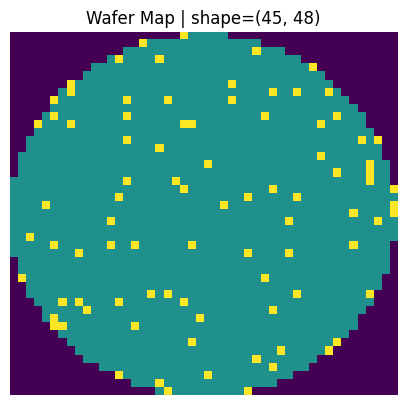

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(
    wafer,
    interpolation="nearest"
)

plt.title(f"Wafer Map | shape={wafer.shape}")
plt.axis("off")
plt.show()

In [ ]:
print("failureType type:")
print(type(df["failureType"].iloc[0]))

print("\nfirst value:")
print(repr(df["failureType"].iloc[0]))

print("\nfirst 20 samples:")
for i in range(20):
    print(i, repr(df["failureType"].iloc[i]))

failureType type:
<class 'numpy.ndarray'>

first value:
array([['none']], dtype='<U4')

first 20 samples:
0 array([['none']], dtype='<U4')
1 array([['none']], dtype='<U4')
2 array([['none']], dtype='<U4')
3 array([['none']], dtype='<U4')
4 array([['none']], dtype='<U4')
5 array([['none']], dtype='<U4')
6 array([['none']], dtype='<U4')
7 array([['none']], dtype='<U4')
8 array([['none']], dtype='<U4')
9 array([['none']], dtype='<U4')
10 array([['none']], dtype='<U4')
11 array([['none']], dtype='<U4')
12 array([['none']], dtype='<U4')
13 array([['none']], dtype='<U4')
14 array([['none']], dtype='<U4')
15 array([['none']], dtype='<U4')
16 array([['none']], dtype='<U4')
17 array([['none']], dtype='<U4')
18 array([['none']], dtype='<U4')
19 array([['Loc']], dtype='<U3')


In [ ]:
print("trianTestLabel type:")
print(type(df["trianTestLabel"].iloc[0]))

print("\nfirst value:")
print(repr(df["trianTestLabel"].iloc[0]))

print("\nfirst 10 samples:")
for i in range(10):
    print(i, repr(df["trianTestLabel"].iloc[i]))

trianTestLabel type:
<class 'numpy.ndarray'>

first value:
array([['Training']], dtype='<U8')

first 10 samples:
0 array([['Training']], dtype='<U8')
1 array([['Training']], dtype='<U8')
2 array([['Training']], dtype='<U8')
3 array([['Training']], dtype='<U8')
4 array([['Training']], dtype='<U8')
5 array([['Training']], dtype='<U8')
6 array([['Training']], dtype='<U8')
7 array([['Training']], dtype='<U8')
8 array([['Training']], dtype='<U8')
9 array([['Training']], dtype='<U8')


In [ ]:
print("Unique lots:", df["lotName"].nunique())

lot_sizes = df.groupby("lotName").size()

print("\nLot size statistics:")
print(lot_sizes.describe())

Unique lots: 46293

Lot size statistics:
count    46293.000000
mean        17.528719
std          8.964477
min          1.000000
25%         10.000000
50%         24.000000
75%         25.000000
max         25.000000
dtype: float64


In [ ]:
print(df["lotName"].head(20).tolist())

[np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1'), np.str_('lot1')]


In [ ]:
df["failureType_clean"] = (
    df["failureType"]
    .apply(unwrap_label)
)

print(
    df["failureType_clean"]
    .value_counts(dropna=False)
)

NameError: name 'unwrap_label' is not defined

In [ ]:
labeled_df = df[
    df["failureType_clean"].notna()
].copy()

print("전체 wafer:", len(df))
print("라벨 wafer:", len(labeled_df))
print("라벨 없는 wafer:", df["failureType_clean"].isna().sum())

print("\nClass distribution:")
print(
    labeled_df["failureType_clean"]
    .value_counts()
)

In [ ]:
class_counts = (
    labeled_df["failureType_clean"]
    .value_counts()
)

plt.figure(figsize=(10, 5))

class_counts.plot(kind="bar")

plt.title("WM-811K Failure Type Distribution")
plt.xlabel("Failure Type")
plt.ylabel("Number of Wafers")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
classes = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full"
]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, cls in zip(axes.flat, classes):

    sample = labeled_df[
        labeled_df["failureType_clean"] == cls
    ].iloc[0]

    wafer = sample["waferMap"]

    ax.imshow(
        wafer,
        interpolation="nearest"
    )

    ax.set_title(
        f"{cls}\n{wafer.shape}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
SAVE_PATH = PROCESSED_DIR / "wm811k_labeled.pkl"

labeled_df.to_pickle(SAVE_PATH)

print("Saved:", SAVE_PATH)
print(
    "File size:",
    round(
        SAVE_PATH.stat().st_size / (1024**3),
        3
    ),
    "GB"
)



WM-811K 다운로드
        ↓
LSWMD.pkl 로딩 성공
        ↓
811,457 wafer 확인
        ↓
6개 column 구조 확인
        ↓
waferMap 직접 시각화
        ↓
failureType ndarray 구조 확인
        ↓
None vs "none" 구분
        ↓
172,950 labeled wafer 확인
        ↓
9개 class 분포 확인
        ↓
46,293 lot 확인
        ↓
lot-aware split 필요성 확인

In [ ]:
labeled_df = pd.read_pickle(
    PROCESSED_DIR / "wm811k_labeled.pkl"
)

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

PROJECT_DIR = Path("/content/drive/MyDrive/wafer_map_project")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

labeled_df = pd.read_pickle(
    PROCESSED_DIR / "wm811k_labeled.pkl"
)

print(labeled_df.shape)
print(labeled_df.columns.tolist())

In [ ]:
classes = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full"
]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, cls in zip(axes.flat, classes):

    sample = labeled_df[
        labeled_df["failureType_clean"] == cls
    ].iloc[0]

    wafer = sample["waferMap"]

    ax.imshow(
        wafer,
        interpolation="nearest"
    )

    ax.set_title(
        f"{cls}\nshape={wafer.shape}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
labeled_df["height"] = labeled_df["waferMap"].apply(
    lambda x: x.shape[0]
)

labeled_df["width"] = labeled_df["waferMap"].apply(
    lambda x: x.shape[1]
)

labeled_df[["height", "width"]].describe()

In [ ]:
shape_counts = (
    labeled_df
    .groupby(["height", "width"])
    .size()
    .sort_values(ascending=False)
)

print("Unique shapes:", len(shape_counts))

display(shape_counts.head(20))

In [ ]:
square_mask = (
    labeled_df["height"]
    == labeled_df["width"]
)

print(
    "Square:",
    square_mask.sum()
)

print(
    "Non-square:",
    (~square_mask).sum()
)

print(
    "Non-square ratio:",
    round(
        (~square_mask).mean() * 100,
        2
    ),
    "%"
)

In [ ]:
import cv2

In [ ]:
def resize_wafer(
    wafer,
    target_size=64
):
    resized = cv2.resize(
        wafer.astype(np.uint8),
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST
    )

    return resized

In [ ]:
def resize_with_padding(
    wafer,
    target_size=64
):
    h, w = wafer.shape

    scale = min(
        target_size / h,
        target_size / w
    )

    new_h = max(
        1,
        int(round(h * scale))
    )

    new_w = max(
        1,
        int(round(w * scale))
    )

    resized = cv2.resize(
        wafer.astype(np.uint8),
        (new_w, new_h),
        interpolation=cv2.INTER_NEAREST
    )

    canvas = np.zeros(
        (target_size, target_size),
        dtype=np.uint8
    )

    top = (
        target_size - new_h
    ) // 2

    left = (
        target_size - new_w
    ) // 2

    canvas[
        top:top + new_h,
        left:left + new_w
    ] = resized

    return canvas

In [ ]:
sample_row = labeled_df[
    labeled_df["height"]
    != labeled_df["width"]
].iloc[0]

original = sample_row["waferMap"]

resized = resize_wafer(original)

padded = resize_with_padding(original)

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    original,
    interpolation="nearest"
)

axes[0].set_title(
    f"Original\n{original.shape}"
)

axes[1].imshow(
    resized,
    interpolation="nearest"
)

axes[1].set_title(
    "64x64 Resize"
)

axes[2].imshow(
    padded,
    interpolation="nearest"
)

axes[2].set_title(
    "Aspect Ratio + Padding"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(
    len(classes),
    3,
    figsize=(10, 28)
)

for row_idx, cls in enumerate(classes):

    sample = labeled_df[
        labeled_df[
            "failureType_clean"
        ] == cls
    ].iloc[0]

    original = sample["waferMap"]

    resized = resize_wafer(
        original
    )

    padded = resize_with_padding(
        original
    )

    axes[row_idx, 0].imshow(
        original,
        interpolation="nearest"
    )

    axes[row_idx, 1].imshow(
        resized,
        interpolation="nearest"
    )

    axes[row_idx, 2].imshow(
        padded,
        interpolation="nearest"
    )

    axes[row_idx, 0].set_ylabel(
        cls,
        fontsize=12
    )

    axes[row_idx, 0].set_title(
        f"Original\n{original.shape}"
    )

    axes[row_idx, 1].set_title(
        "Resize"
    )

    axes[row_idx, 2].set_title(
        "Padding"
    )

    for col in range(3):
        axes[row_idx, col].axis(
            "off"
        )

plt.tight_layout()
plt.show()

In [ ]:
label_map = {
    "none": 0,
    "Center": 1,
    "Donut": 2,
    "Edge-Loc": 3,
    "Edge-Ring": 4,
    "Loc": 5,
    "Random": 6,
    "Scratch": 7,
    "Near-full": 8
}

In [ ]:
labeled_df["label"] = (
    labeled_df[
        "failureType_clean"
    ]
    .map(label_map)
)

print(
    labeled_df[
        [
            "failureType_clean",
            "label"
        ]
    ]
    .head(20)
)

In [ ]:
print(
    labeled_df["label"]
    .value_counts()
    .sort_index()
)

In [ ]:
print(
    "Missing labels:",
    labeled_df[
        "label"
    ].isna().sum()
)

In [ ]:
id_to_label = {
    v: k
    for k, v
    in label_map.items()
}

print(id_to_label)

In [ ]:
class_stats = (
    labeled_df[
        "failureType_clean"
    ]
    .value_counts()
    .rename("count")
    .to_frame()
)

class_stats["ratio"] = (
    class_stats["count"]
    / len(labeled_df)
)

class_stats["percent"] = (
    class_stats["ratio"]
    * 100
)

display(class_stats)

In [ ]:
defect_df = labeled_df[
    labeled_df[
        "failureType_clean"
    ] != "none"
]

defect_counts = (
    defect_df[
        "failureType_clean"
    ]
    .value_counts()
)

defect_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "WM-811K Defect Pattern Distribution"
)

plt.ylabel(
    "Number of Wafers"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

In [ ]:
SAVE_PATH = (
    PROCESSED_DIR
    / "wm811k_labeled_v2.pkl"
)

labeled_df.to_pickle(
    SAVE_PATH
)

print(
    "Saved:",
    SAVE_PATH
)

Day 1
━━━━━━━━━━━━━━━━━━━━
WM-811K 확보                 ✓
LSWMD.pkl 로딩              ✓
811,457 wafer 확인          ✓
failureType 구조 확인       ✓
172,950 labeled wafer       ✓
46,293 lots 확인            ✓

Day 2
━━━━━━━━━━━━━━━━━━━━
9개 class 시각화             ✓
wafer shape 분석             ✓
resize 함수                  ✓
padding 함수                 ✓
전처리 비교                  ✓
nearest interpolation        ✓
label encoding               ✓
class imbalance 확인         ✓


In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

PROJECT_DIR = Path("/content/drive/MyDrive/wafer_map_project")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

labeled_df = pd.read_pickle(
    PROCESSED_DIR / "wm811k_labeled_v2.pkl"
)

print(labeled_df.shape)
print(labeled_df.columns.tolist())

In [ ]:
print(
    labeled_df["failureType_clean"]
    .value_counts()
)

print(
    "Unique lots:",
    labeled_df["lotName"].nunique()
)

In [ ]:
print("Missing label:", labeled_df["label"].isna().sum())
print("Missing lot:", labeled_df["lotName"].isna().sum())

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

In [ ]:
gss_1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=42
)

train_idx, temp_idx = next(
    gss_1.split(
        labeled_df,
        groups=labeled_df["lotName"]
    )
)

train_df = labeled_df.iloc[train_idx].copy()
temp_df = labeled_df.iloc[temp_idx].copy()

print("Train:", len(train_df))
print("Temp :", len(temp_df))

In [ ]:
gss_2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss_2.split(
        temp_df,
        groups=temp_df["lotName"]
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

In [ ]:
total = len(labeled_df)

print(
    "Train ratio:",
    round(len(train_df) / total, 4)
)

print(
    "Val ratio:",
    round(len(val_df) / total, 4)
)

print(
    "Test ratio:",
    round(len(test_df) / total, 4)
)

In [ ]:
train_lots = set(train_df["lotName"])
val_lots = set(val_df["lotName"])
test_lots = set(test_df["lotName"])

print(
    "Train ∩ Val:",
    len(train_lots & val_lots)
)

print(
    "Train ∩ Test:",
    len(train_lots & test_lots)
)

print(
    "Val ∩ Test:",
    len(val_lots & test_lots)
)

In [ ]:
def class_distribution(df, name):
    counts = (
        df["failureType_clean"]
        .value_counts()
    )

    ratios = (
        df["failureType_clean"]
        .value_counts(normalize=True)
        * 100
    )

    result = pd.DataFrame({
        "count": counts,
        "percent": ratios
    })

    print(f"\n{name}")
    display(result)

class_distribution(train_df, "TRAIN")
class_distribution(val_df, "VALIDATION")
class_distribution(test_df, "TEST")

In [ ]:
dist_df = pd.DataFrame({
    "Train":
        train_df["failureType_clean"]
        .value_counts(normalize=True),

    "Validation":
        val_df["failureType_clean"]
        .value_counts(normalize=True),

    "Test":
        test_df["failureType_clean"]
        .value_counts(normalize=True)
}).fillna(0)

dist_df = dist_df.loc[
    [
        "none",
        "Center",
        "Donut",
        "Edge-Loc",
        "Edge-Ring",
        "Loc",
        "Random",
        "Scratch",
        "Near-full"
    ]
]

display(dist_df)

In [ ]:
dist_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Class Distribution by Split"
)

plt.ylabel(
    "Ratio"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

In [ ]:
train_path = PROCESSED_DIR / "train_lot_split.pkl"
val_path = PROCESSED_DIR / "val_lot_split.pkl"
test_path = PROCESSED_DIR / "test_lot_split.pkl"

train_df.to_pickle(train_path)
val_df.to_pickle(val_path)
test_df.to_pickle(test_path)

print("Saved")
print(train_path)
print(val_path)
print(test_path)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2

In [ ]:
def resize_wafer(
    wafer,
    target_size=64
):
    return cv2.resize(
        wafer.astype(np.uint8),
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST
    )

In [ ]:
class WaferDataset(Dataset):

    def __init__(
        self,
        dataframe,
        target_size=64
    ):
        self.df = (
            dataframe
            .reset_index(drop=True)
        )

        self.target_size = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        wafer = row["waferMap"]

        wafer = resize_wafer(
            wafer,
            self.target_size
        )

        wafer = torch.tensor(
            wafer,
            dtype=torch.float32
        )

        wafer = wafer.unsqueeze(0)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long
        )

        return wafer, label

In [ ]:
train_dataset = WaferDataset(
    train_df
)

val_dataset = WaferDataset(
    val_df
)

test_dataset = WaferDataset(
    test_df
)

print(
    len(train_dataset),
    len(val_dataset),
    len(test_dataset)
)

In [ ]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)

print("Label:", label)
print("Label dtype:", label.dtype)

print(
    "Unique values:",
    torch.unique(image)
)

In [ ]:
plt.figure(figsize=(5, 5))

plt.imshow(
    image.squeeze(0),
    interpolation="nearest"
)

plt.title(
    f"Label ID: {label.item()}"
)

plt.axis("off")
plt.show()

In [ ]:
id_to_label = {
    0: "none",
    1: "Center",
    2: "Donut",
    3: "Edge-Loc",
    4: "Edge-Ring",
    5: "Loc",
    6: "Random",
    7: "Scratch",
    8: "Near-full"
}

print(
    id_to_label[
        label.item()
    ]
)

In [ ]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
images, labels = next(
    iter(train_loader)
)

print(
    "Images:",
    images.shape
)

print(
    "Labels:",
    labels.shape
)

print(
    "Labels example:",
    labels[:20]
)

In [ ]:
wafer = wafer / 2.0

In [ ]:
wafer = torch.tensor(
    wafer,
    dtype=torch.float32
) / 2.0

In [ ]:
wafer = torch.tensor(
    wafer,
    dtype=torch.float32
) / 2.0

wafer = wafer.unsqueeze(0)

In [ ]:
image, label = train_dataset[0]

print(
    torch.unique(image)
)

In [ ]:
def unwrap_array_label(x):

    if isinstance(x, np.ndarray):

        if x.size == 0:
            return None

        return str(
            x.reshape(-1)[0]
        )

    return str(x)

In [ ]:
labeled_df[
    "official_split"
] = (
    labeled_df[
        "trianTestLabel"
    ]
    .apply(
        unwrap_array_label
    )
)

In [ ]:
print(
    labeled_df[
        "official_split"
    ]
    .value_counts(
        dropna=False
    )
)

In [ ]:
official_train = labeled_df[
    labeled_df[
        "official_split"
    ] == "Training"
]

official_test = labeled_df[
    labeled_df[
        "official_split"
    ] == "Test"
]

In [ ]:
official_train_lots = set(
    official_train["lotName"]
)

official_test_lots = set(
    official_test["lotName"]
)

overlap = (
    official_train_lots
    &
    official_test_lots
)

print(
    "Official split lot overlap:",
    len(overlap)
)

In [ ]:
train_path = PROCESSED_DIR / "train_lot_split.pkl"
val_path   = PROCESSED_DIR / "val_lot_split.pkl"
test_path  = PROCESSED_DIR / "test_lot_split.pkl"

train_df.to_pickle(train_path)
val_df.to_pickle(val_path)
test_df.to_pickle(test_path)

print("Train:", train_path)
print("Val  :", val_path)
print("Test :", test_path)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2

In [ ]:
def resize_wafer(wafer, target_size=64):
    return cv2.resize(
        wafer.astype(np.uint8),
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST
    )

In [ ]:
class WaferDataset(Dataset):

    def __init__(self, dataframe, target_size=64):
        self.df = dataframe.reset_index(drop=True)
        self.target_size = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        wafer = row["waferMap"]

        wafer = resize_wafer(
            wafer,
            self.target_size
        )

        # 0,1,2 → 0,0.5,1
        wafer = torch.tensor(
            wafer,
            dtype=torch.float32
        ) / 2.0

        # H×W → C×H×W
        wafer = wafer.unsqueeze(0)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long
        )

        return wafer, label

In [ ]:
train_dataset = WaferDataset(train_df)
val_dataset   = WaferDataset(val_df)
test_dataset  = WaferDataset(test_df)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

In [ ]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)

print("Label:", label)
print("Label dtype:", label.dtype)

print("Unique values:", torch.unique(image))

In [ ]:
id_to_label = {
    0: "none",
    1: "Center",
    2: "Donut",
    3: "Edge-Loc",
    4: "Edge-Ring",
    5: "Loc",
    6: "Random",
    7: "Scratch",
    8: "Near-full"
}

plt.figure(figsize=(5, 5))

plt.imshow(
    image.squeeze(0),
    interpolation="nearest"
)

plt.title(
    f"{id_to_label[label.item()]} | label={label.item()}"
)

plt.axis("off")
plt.show()

In [ ]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
shuffle=False

In [ ]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Image min:", images.min().item())
print("Image max:", images.max().item())

print("First 20 labels:")
print(labels[:20])

In [ ]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
import torch.nn as nn

class SimpleCNN(nn.Module):

    def __init__(self, num_classes=9):
        super().__init__()

        self.features = nn.Sequential(

            # 1 × 64 × 64
            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 32 × 32 × 32
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 64 × 16 × 16
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)

            # 128 × 8 × 8
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 8 * 8,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [ ]:
model = SimpleCNN(
    num_classes=9
).to(device)

print(model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropou

In [ ]:
# 1. 필요한 라이브러리
import numpy as np
import pandas as pd
import cv2
import torch

from pathlib import Path
from google.colab import drive
from torch.utils.data import Dataset, DataLoader

# 2. Drive 연결
drive.mount('/content/drive')

PROJECT_DIR = Path("/content/drive/MyDrive/wafer_map_project")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

# 3. Day 3에서 저장한 split 불러오기
train_df = pd.read_pickle(
    PROCESSED_DIR / "train_lot_split.pkl"
)

val_df = pd.read_pickle(
    PROCESSED_DIR / "val_lot_split.pkl"
)

test_df = pd.read_pickle(
    PROCESSED_DIR / "test_lot_split.pkl"
)

print(len(train_df), len(val_df), len(test_df))


Mounted at /content/drive
120979 26116 25855


In [ ]:
def resize_wafer(wafer, target_size=64):
    return cv2.resize(
        wafer.astype(np.uint8),
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST
    )


In [ ]:
class WaferDataset(Dataset):

    def __init__(self, dataframe, target_size=64):
        self.df = dataframe.reset_index(drop=True)
        self.target_size = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        wafer = row["waferMap"]

        wafer = resize_wafer(
            wafer,
            self.target_size
        )

        wafer = torch.tensor(
            wafer,
            dtype=torch.float32
        ) / 2.0

        wafer = wafer.unsqueeze(0)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long
        )

        return wafer, label

In [ ]:
train_dataset = WaferDataset(train_df)
val_dataset = WaferDataset(val_df)
test_dataset = WaferDataset(test_df)

In [ ]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Min:", images.min().item())
print("Max:", images.max().item())

Images: torch.Size([128, 1, 64, 64])
Labels: torch.Size([128])
Min: 0.0
Max: 1.0


In [ ]:
images, labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input :", images.shape)
print("Output:", outputs.shape)

NameError: name 'device' is not defined

In [ ]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [ ]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        preds = outputs.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
def evaluate_model(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            preds = outputs.argmax(dim=1)

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

    loss = running_loss / total
    accuracy = correct / total

    return (
        loss,
        accuracy,
        all_labels,
        all_preds
    )

In [ ]:
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score
)

In [ ]:
from pathlib import Path

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    MODEL_DIR /
    "baseline_cnn_best.pt"
)

In [ ]:
EPOCHS = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
    "val_balanced_acc": []
}

best_macro_f1 = -1.0

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_acc,
        y_true,
        y_pred
    ) = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    val_macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    val_balanced_acc = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(
        val_macro_f1
    )
    history["val_balanced_acc"].append(
        val_balanced_acc
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f} | "
        f"Macro-F1 {val_macro_f1:.4f} | "
        f"Balanced Acc {val_balanced_acc:.4f}"
    )

    if val_macro_f1 > best_macro_f1:

        best_macro_f1 = val_macro_f1

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print("  → Best model saved")

In [ ]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.to(device)

print("Loaded:", BEST_MODEL_PATH)
print("Best Validation Macro-F1:", best_macro_f1)

In [ ]:
(
    test_loss,
    test_acc,
    test_true,
    test_pred
) = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

In [ ]:
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score
)

test_macro_f1 = f1_score(
    test_true,
    test_pred,
    average="macro"
)

test_balanced_acc = balanced_accuracy_score(
    test_true,
    test_pred
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print(
    "Test Balanced Accuracy:",
    round(test_balanced_acc, 4)
)
print(
    "Test Macro-F1:",
    round(test_macro_f1, 4)
)

In [ ]:
from sklearn.metrics import classification_report

class_names = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full"
]

print(
    classification_report(
        test_true,
        test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

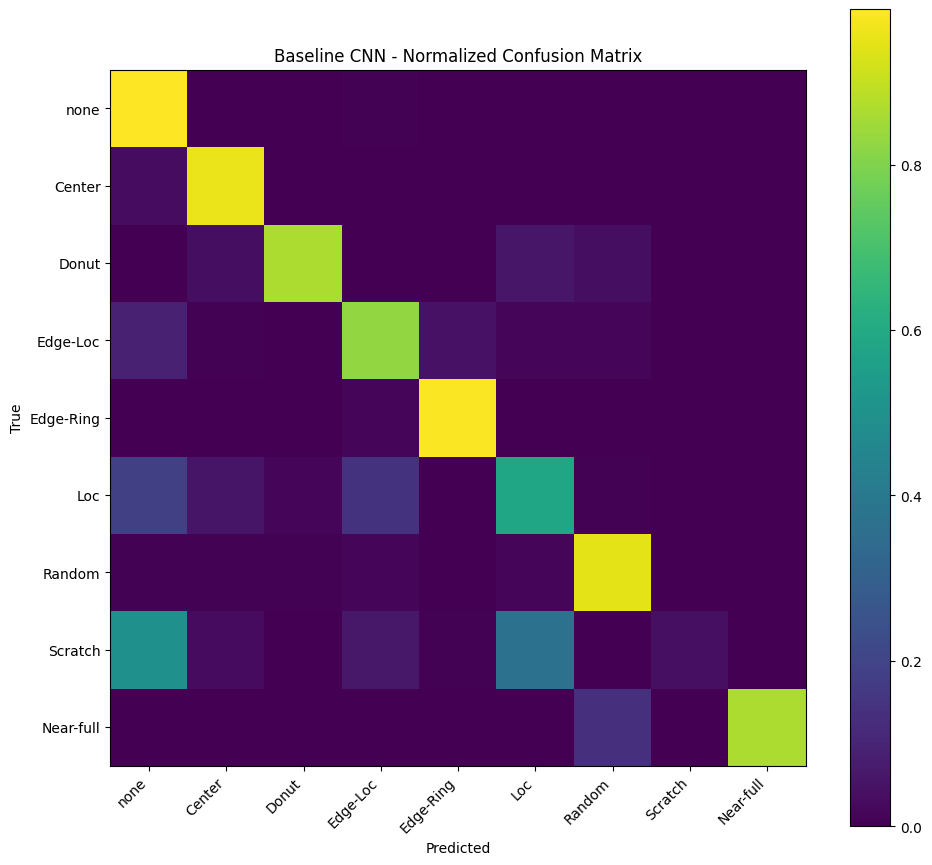

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_true,
    test_pred
)

cm_norm = (
    cm.astype(float)
    /
    cm.sum(axis=1, keepdims=True)
)

fig, ax = plt.subplots(
    figsize=(10, 9)
)

im = ax.imshow(cm_norm)

ax.set_xticks(
    np.arange(len(class_names))
)

ax.set_yticks(
    np.arange(len(class_names))
)

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    class_names
)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")

ax.set_title(
    "Baseline CNN - Normalized Confusion Matrix"
)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
train_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

print(train_counts)

label
0    103101
1      3008
2       366
3      3630
4      6871
5      2411
6       614
7       871
8       107
Name: count, dtype: int64


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

classes = np.arange(9)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class weights:")

for i, weight in enumerate(class_weights):
    print(
        f"{i}: {class_names[i]:10s} "
        f"→ {weight.item():.4f}"
    )

Class weights:
0: none       → 0.1304
1: Center     → 4.4688
2: Donut      → 36.7271
3: Edge-Loc   → 3.7031
4: Edge-Ring  → 1.9564
5: Loc        → 5.5753
6: Random     → 21.8927
7: Scratch    → 15.4330
8: Near-full  → 125.6272


In [ ]:
weighted_model = SimpleCNN(
    num_classes=9
).to(device)

In [ ]:
weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

In [ ]:
weighted_optimizer = torch.optim.Adam(
    weighted_model.parameters(),
    lr=1e-3
)

In [ ]:
# ------------------------------------------------------------
# wafer resize
# ------------------------------------------------------------

def resize_wafer(
    wafer,
    target_size=64
):
    return cv2.resize(
        wafer.astype(np.uint8),
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST
    )


# ------------------------------------------------------------
# PyTorch Dataset
# ------------------------------------------------------------

class WaferDataset(Dataset):

    def __init__(
        self,
        dataframe,
        target_size=64
    ):
        self.df = (
            dataframe
            .reset_index(drop=True)
        )

        self.target_size = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        wafer = row["waferMap"]

        wafer = resize_wafer(
            wafer,
            self.target_size
        )

        # 0 / 1 / 2
        # →
        # 0 / 0.5 / 1
        wafer = torch.tensor(
            wafer,
            dtype=torch.float32
        ) / 2.0

        # [64,64] → [1,64,64]
        wafer = wafer.unsqueeze(0)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long
        )

        return wafer, label


# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

train_dataset = WaferDataset(train_df)
val_dataset   = WaferDataset(val_df)
test_dataset  = WaferDataset(test_df)

# ------------------------------------------------------------
# DataLoader
# ------------------------------------------------------------

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, labels = next(
    iter(train_loader)
)

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([128, 1, 64, 64])
Labels: torch.Size([128])


In [ ]:
# ============================================================
# Day 5 재시작용 초기 실행
# ============================================================

from google.colab import drive
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    recall_score
)

from sklearn.utils.class_weight import compute_class_weight

# Google Drive 연결
drive.mount('/content/drive')

# ------------------------------------------------------------
# 프로젝트 경로
# ------------------------------------------------------------

PROJECT_DIR = Path(
    "/content/drive/MyDrive/wafer_map_project"
)

PROCESSED_DIR = (
    PROJECT_DIR / "data" / "processed"
)

MODEL_DIR = (
    PROJECT_DIR / "models"
)

RESULTS_DIR = (
    PROJECT_DIR / "results"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# GPU
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

# ------------------------------------------------------------
# 클래스 이름
# ------------------------------------------------------------

class_names = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full"
]

# ------------------------------------------------------------
# Day 3에서 저장한 split 불러오기
# ------------------------------------------------------------

train_df = pd.read_pickle(
    PROCESSED_DIR / "train_lot_split.pkl"
)

val_df = pd.read_pickle(
    PROCESSED_DIR / "val_lot_split.pkl"
)

test_df = pd.read_pickle(
    PROCESSED_DIR / "test_lot_split.pkl"
)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
Train: 120979
Val  : 26116
Test : 25855


In [ ]:
# ------------------------------------------------------------
# wafer resize
# ------------------------------------------------------------

def resize_wafer(
    wafer,
    target_size=64
):
    return cv2.resize(
        wafer.astype(np.uint8),
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST
    )


# ------------------------------------------------------------
# PyTorch Dataset
# ------------------------------------------------------------

class WaferDataset(Dataset):

    def __init__(
        self,
        dataframe,
        target_size=64
    ):
        self.df = (
            dataframe
            .reset_index(drop=True)
        )

        self.target_size = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        wafer = row["waferMap"]

        wafer = resize_wafer(
            wafer,
            self.target_size
        )

        # 0 / 1 / 2
        # →
        # 0 / 0.5 / 1
        wafer = torch.tensor(
            wafer,
            dtype=torch.float32
        ) / 2.0

        # [64,64] → [1,64,64]
        wafer = wafer.unsqueeze(0)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long
        )

        return wafer, label


# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

train_dataset = WaferDataset(train_df)
val_dataset   = WaferDataset(val_df)
test_dataset  = WaferDataset(test_df)

# ------------------------------------------------------------
# DataLoader
# ------------------------------------------------------------

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, labels = next(
    iter(train_loader)
)

print("Images:", images.shape)
print("Labels:", labels.shape)

class SimpleCNN(nn.Module):

    def __init__(
        self,
        num_classes=9
    ):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 8 * 8,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

Images: torch.Size([128, 1, 64, 64])
Labels: torch.Size([128])


In [ ]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        preds = outputs.argmax(
            dim=1
        )

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total
    )


def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            preds = outputs.argmax(
                dim=1
            )

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

    return (
        running_loss / total,
        correct / total,
        all_labels,
        all_preds
    )

In [ ]:
BASELINE_MODEL_PATH = (
    MODEL_DIR
    / "baseline_cnn_best.pt"
)

baseline_model = SimpleCNN(
    num_classes=9
).to(device)

baseline_model.load_state_dict(
    torch.load(
        BASELINE_MODEL_PATH,
        map_location=device
    )
)

baseline_criterion = (
    nn.CrossEntropyLoss()
)

(
    test_loss,
    test_acc,
    test_true,
    test_pred
) = evaluate_model(
    baseline_model,
    test_loader,
    baseline_criterion,
    device
)

test_macro_f1 = f1_score(
    test_true,
    test_pred,
    average="macro"
)

test_balanced_acc = (
    balanced_accuracy_score(
        test_true,
        test_pred
    )
)

print(
    "Baseline Accuracy:",
    round(test_acc, 4)
)

print(
    "Baseline Balanced Accuracy:",
    round(test_balanced_acc, 4)
)

print(
    "Baseline Macro-F1:",
    round(test_macro_f1, 4)
)

Baseline Accuracy: 0.9663
Baseline Balanced Accuracy: 0.7851
Baseline Macro-F1: 0.7745


In [ ]:
train_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

print(train_counts)

label
0    103101
1      3008
2       366
3      3630
4      6871
5      2411
6       614
7       871
8       107
Name: count, dtype: int64


In [ ]:
classes = np.arange(9)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nClass weights:")

for i, weight in enumerate(
    class_weights
):
    print(
        f"{i} | "
        f"{class_names[i]:10s} | "
        f"{weight.item():.4f}"
    )


Class weights:
0 | none       | 0.1304
1 | Center     | 4.4688
2 | Donut      | 36.7271
3 | Edge-Loc   | 3.7031
4 | Edge-Ring  | 1.9564
5 | Loc        | 5.5753
6 | Random     | 21.8927
7 | Scratch    | 15.4330
8 | Near-full  | 125.6272


In [ ]:
# ============================================================
# DAY 5 - Class Weighted CNN
# ============================================================

# Baseline과 동일한 CNN 구조를 새로 초기화
weighted_model = SimpleCNN(
    num_classes=9
).to(device)

# 클래스별 가중치를 적용한 CrossEntropyLoss
weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Baseline과 동일한 optimizer / learning rate
weighted_optimizer = torch.optim.Adam(
    weighted_model.parameters(),
    lr=1e-3
)

# Weighted 모델 저장 경로
WEIGHTED_MODEL_PATH = (
    MODEL_DIR / "weighted_cnn_best.pt"
)

EPOCHS = 10

weighted_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
    "val_balanced_acc": []
}

weighted_best_macro_f1 = -1.0

In [ ]:
for epoch in range(1, EPOCHS + 1):

    # -----------------------------
    # Train
    # -----------------------------
    train_loss, train_acc = train_one_epoch(
        weighted_model,
        train_loader,
        weighted_criterion,
        weighted_optimizer,
        device
    )

    # -----------------------------
    # Validation
    # -----------------------------
    (
        val_loss,
        val_acc,
        y_true,
        y_pred
    ) = evaluate_model(
        weighted_model,
        val_loader,
        weighted_criterion,
        device
    )

    # 불균형 데이터 평가 지표
    val_macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    val_balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    # History 저장
    weighted_history["train_loss"].append(train_loss)
    weighted_history["train_acc"].append(train_acc)
    weighted_history["val_loss"].append(val_loss)
    weighted_history["val_acc"].append(val_acc)
    weighted_history["val_macro_f1"].append(val_macro_f1)
    weighted_history["val_balanced_acc"].append(val_balanced_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f} | "
        f"Macro-F1 {val_macro_f1:.4f} | "
        f"Balanced Acc {val_balanced_acc:.4f}"
    )

    # Baseline과 동일하게
    # Validation Macro-F1 기준으로 best model 선택
    if val_macro_f1 > weighted_best_macro_f1:

        weighted_best_macro_f1 = val_macro_f1

        torch.save(
            weighted_model.state_dict(),
            WEIGHTED_MODEL_PATH
        )

        print("  → Best weighted model saved")

Epoch 01/10 | Train Loss 1.2026 | Train Acc 0.4533 | Val Loss 1.2234 | Val Acc 0.1498 | Macro-F1 0.5005 | Balanced Acc 0.6377
  → Best weighted model saved
Epoch 02/10 | Train Loss 0.8857 | Train Acc 0.6111 | Val Loss 0.9652 | Val Acc 0.8955 | Macro-F1 0.6046 | Balanced Acc 0.7012
  → Best weighted model saved
Epoch 03/10 | Train Loss 0.8132 | Train Acc 0.6722 | Val Loss 0.9206 | Val Acc 0.9115 | Macro-F1 0.6681 | Balanced Acc 0.7315
  → Best weighted model saved
Epoch 04/10 | Train Loss 0.7078 | Train Acc 0.7304 | Val Loss 0.7815 | Val Acc 0.8760 | Macro-F1 0.7040 | Balanced Acc 0.8010
  → Best weighted model saved
Epoch 05/10 | Train Loss 0.6380 | Train Acc 0.7521 | Val Loss 1.2814 | Val Acc 0.3721 | Macro-F1 0.4370 | Balanced Acc 0.6946
Epoch 06/10 | Train Loss 0.6129 | Train Acc 0.7724 | Val Loss 0.6472 | Val Acc 0.9179 | Macro-F1 0.7177 | Balanced Acc 0.8127
  → Best weighted model saved
Epoch 07/10 | Train Loss 0.5488 | Train Acc 0.7996 | Val Loss 0.6912 | Val Acc 0.8043 | Macro-

In [ ]:
# Best weighted 모델 불러오기
weighted_model.load_state_dict(
    torch.load(
        WEIGHTED_MODEL_PATH,
        map_location=device
    )
)

weighted_model.to(device)

print(
    "Best Validation Macro-F1:",
    weighted_best_macro_f1
)

Best Validation Macro-F1: 0.7385771435344276


In [ ]:
(
    weighted_test_loss,
    weighted_test_acc,
    weighted_test_true,
    weighted_test_pred
) = evaluate_model(
    weighted_model,
    test_loader,
    weighted_criterion,
    device
)

weighted_test_macro_f1 = f1_score(
    weighted_test_true,
    weighted_test_pred,
    average="macro"
)

weighted_test_balanced_acc = balanced_accuracy_score(
    weighted_test_true,
    weighted_test_pred
)

print(
    "Weighted Test Accuracy:",
    round(weighted_test_acc, 4)
)

print(
    "Weighted Test Balanced Accuracy:",
    round(weighted_test_balanced_acc, 4)
)

print(
    "Weighted Test Macro-F1:",
    round(weighted_test_macro_f1, 4)
)

Weighted Test Accuracy: 0.933
Weighted Test Balanced Accuracy: 0.8356
Weighted Test Macro-F1: 0.7534


In [ ]:
print(
    classification_report(
        weighted_test_true,
        weighted_test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        none     0.9907    0.9463    0.9680     22066
      Center     0.7791    0.9536    0.8576       603
       Donut     0.6923    0.9759    0.8100        83
    Edge-Loc     0.5089    0.8536    0.6376       772
   Edge-Ring     0.9705    0.9665    0.9685      1432
         Loc     0.5029    0.5920    0.5439       576
      Random     0.7812    0.9542    0.8591       131
     Scratch     0.1758    0.3446    0.2328       177
   Near-full     0.8750    0.9333    0.9032        15

    accuracy                         0.9330     25855
   macro avg     0.6974    0.8356    0.7534     25855
weighted avg     0.9517    0.9330    0.9400     25855



In [ ]:
weighted_model.load_state_dict(
    torch.load(
        WEIGHTED_MODEL_PATH,
        map_location=device
    )
)

weighted_model.to(device)

print(
    "Best Validation Macro-F1:",
    weighted_best_macro_f1
)

Best Validation Macro-F1: 0.7385771435344276


In [ ]:
(
    weighted_test_loss,
    weighted_test_acc,
    weighted_test_true,
    weighted_test_pred
) = evaluate_model(
    weighted_model,
    test_loader,
    weighted_criterion,
    device
)

weighted_test_macro_f1 = f1_score(
    weighted_test_true,
    weighted_test_pred,
    average="macro"
)

weighted_test_balanced_acc = balanced_accuracy_score(
    weighted_test_true,
    weighted_test_pred
)

print(
    "Weighted Test Accuracy:",
    round(weighted_test_acc, 4)
)

print(
    "Weighted Test Balanced Accuracy:",
    round(weighted_test_balanced_acc, 4)
)

print(
    "Weighted Test Macro-F1:",
    round(weighted_test_macro_f1, 4)
)

Weighted Test Accuracy: 0.933
Weighted Test Balanced Accuracy: 0.8356
Weighted Test Macro-F1: 0.7534


In [ ]:
print(
    classification_report(
        weighted_test_true,
        weighted_test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

In [ ]:
baseline_recall = recall_score(
    test_true,
    test_pred,
    labels=np.arange(9),
    average=None
)

weighted_recall = recall_score(
    weighted_test_true,
    weighted_test_pred,
    labels=np.arange(9),
    average=None
)

recall_comparison = pd.DataFrame({
    "Class": class_names,
    "Baseline Recall": baseline_recall,
    "Weighted Recall": weighted_recall
})

recall_comparison["Change"] = (
    recall_comparison["Weighted Recall"]
    -
    recall_comparison["Baseline Recall"]
)

display(recall_comparison)

,Class,Baseline Recall,Weighted Recall,Change
0,none,0.988081,0.946343,-0.041738
1,Center,0.960199,0.953566,-0.006633
2,Donut,0.867470,0.975904,0.108434
3,Edge-Loc,0.829016,0.853627,0.024611
4,Edge-Ring,0.983240,0.966480,-0.016760
5,Loc,0.585069,0.592014,0.006944
6,Random,0.946565,0.954198,0.007634
7,Scratch,0.039548,0.344633,0.305085
8,Near-full,0.866667,0.933333,0.066667


In [9]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    baseline_model = SimpleCNN(
    num_classes=9
).to(device)
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/wafer_map_project"
)

MODEL_DIR = PROJECT_DIR / "models"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "results"

print("MODEL_DIR:", MODEL_DIR)
print("Exists:", MODEL_DIR.exists())

Device: cuda
GPU: Tesla T4
MODEL_DIR: /content/drive/MyDrive/wafer_map_project/models
Exists: False


In [10]:
# ============================================================
# SimpleCNN 클래스 다시 정의
# ============================================================

import torch
import torch.nn as nn

class SimpleCNN(nn.Module):

    def __init__(self, num_classes=9):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1, 32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 8 * 8,
                256
            ),

            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("SimpleCNN loaded")
# ============================================================
# Baseline 모델 복구
# ============================================================

baseline_model = SimpleCNN(num_classes=9).to(device)

baseline_model.load_state_dict(
    torch.load(
        MODEL_DIR / "baseline_cnn_best.pt",
        map_location=device
    )
)

baseline_criterion = nn.CrossEntropyLoss()

(
    baseline_test_loss,
    baseline_test_acc,
    test_true,
    test_pred
) = evaluate_model(
    baseline_model,
    test_loader,
    baseline_criterion,
    device
)

SimpleCNN loaded


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/wafer_map_project/models/baseline_cnn_best.pt'

In [ ]:
# ============================================================
# Weighted 모델 복구
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

classes = np.arange(9)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

weighted_model = SimpleCNN(
    num_classes=9
).to(device)

weighted_model.load_state_dict(
    torch.load(
        MODEL_DIR / "weighted_cnn_best.pt",
        map_location=device
    )
)

weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

(
    weighted_test_loss,
    weighted_test_acc,
    weighted_test_true,
    weighted_test_pred
) = evaluate_model(
    weighted_model,
    test_loader,
    weighted_criterion,
    device
)

In [ ]:
from sklearn.metrics import recall_score

baseline_recall = recall_score(
    test_true,
    test_pred,
    labels=np.arange(9),
    average=None
)

weighted_recall = recall_score(
    weighted_test_true,
    weighted_test_pred,
    labels=np.arange(9),
    average=None
)

recall_comparison = pd.DataFrame({
    "Class": class_names,
    "Baseline Recall": baseline_recall,
    "Weighted Recall": weighted_recall
})

recall_comparison["Change"] = (
    recall_comparison["Weighted Recall"]
    - recall_comparison["Baseline Recall"]
)

display(recall_comparison)

In [8]:
baseline_macro_f1 = f1_score(
    test_true,
    test_pred,
    average="macro"
)

baseline_balanced_acc = balanced_accuracy_score(
    test_true,
    test_pred
)

weighted_macro_f1 = f1_score(
    weighted_test_true,
    weighted_test_pred,
    average="macro"
)

weighted_balanced_acc = balanced_accuracy_score(
    weighted_test_true,
    weighted_test_pred
)

comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Weighted CNN"
    ],
    "Accuracy": [
        baseline_test_acc,
        weighted_test_acc
    ],
    "Balanced Accuracy": [
        baseline_balanced_acc,
        weighted_balanced_acc
    ],
    "Macro F1": [
        baseline_macro_f1,
        weighted_macro_f1
    ]
})

display(comparison)

NameError: name 'f1_score' is not defined

In [1]:
# ============================================================
# Baseline 모델 복구
# ============================================================

baseline_model = SimpleCNN(num_classes=9).to(device)

baseline_model.load_state_dict(
    torch.load(
        MODEL_DIR / "baseline_cnn_best.pt",
        map_location=device
    )
)

baseline_criterion = nn.CrossEntropyLoss()

(
    baseline_test_loss,
    baseline_test_acc,
    test_true,
    test_pred
) = evaluate_model(
    baseline_model,
    test_loader,
    baseline_criterion,
    device
)
# ============================================================
# Weighted 모델 복구
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

classes = np.arange(9)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

weighted_model = SimpleCNN(
    num_classes=9
).to(device)

weighted_model.load_state_dict(
    torch.load(
        MODEL_DIR / "weighted_cnn_best.pt",
        map_location=device
    )
)

weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

(
    weighted_test_loss,
    weighted_test_acc,
    weighted_test_true,
    weighted_test_pred
) = evaluate_model(
    weighted_model,
    test_loader,
    weighted_criterion,
    device
)
from sklearn.metrics import recall_score

baseline_recall = recall_score(
    test_true,
    test_pred,
    labels=np.arange(9),
    average=None
)

weighted_recall = recall_score(
    weighted_test_true,
    weighted_test_pred,
    labels=np.arange(9),
    average=None
)

recall_comparison = pd.DataFrame({
    "Class": class_names,
    "Baseline Recall": baseline_recall,
    "Weighted Recall": weighted_recall
})

recall_comparison["Change"] = (
    recall_comparison["Weighted Recall"]
    - recall_comparison["Baseline Recall"]
)

display(recall_comparison)
baseline_macro_f1 = f1_score(
    test_true,
    test_pred,
    average="macro"
)

baseline_balanced_acc = balanced_accuracy_score(
    test_true,
    test_pred
)

weighted_macro_f1 = f1_score(
    weighted_test_true,
    weighted_test_pred,
    average="macro"
)

weighted_balanced_acc = balanced_accuracy_score(
    weighted_test_true,
    weighted_test_pred
)

comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Weighted CNN"
    ],
    "Accuracy": [
        baseline_test_acc,
        weighted_test_acc
    ],
    "Balanced Accuracy": [
        baseline_balanced_acc,
        weighted_balanced_acc
    ],
    "Macro F1": [
        baseline_macro_f1,
        weighted_macro_f1
    ]
})

display(comparison)

NameError: name 'SimpleCNN' is not defined

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/wafer_map_project"
)

print("PROJECT exists:", PROJECT_DIR.exists())

for p in PROJECT_DIR.iterdir():
    print(p)
    MODEL_DIR = PROJECT_DIR / "models"

print("MODEL_DIR exists:", MODEL_DIR.exists())

if MODEL_DIR.exists():
    print(list(MODEL_DIR.iterdir()))

    drive_root = Path(
    "/content/drive/MyDrive"
)

baseline_files = list(
    drive_root.rglob("baseline_cnn_best.pt")
)

weighted_files = list(
    drive_root.rglob("weighted_cnn_best.pt")
)

print("Baseline files:")
for p in baseline_files:
    print(p)

print("\nWeighted files:")
for p in weighted_files:
    print(p)

    BASELINE_MODEL_PATH = baseline_files[0]
WEIGHTED_MODEL_PATH = weighted_files[0]

print(BASELINE_MODEL_PATH)
print(WEIGHTED_MODEL_PATH)


baseline_model = SimpleCNN(
    num_classes=9
).to(device)

baseline_model.load_state_dict(
    torch.load(
        BASELINE_MODEL_PATH,
        map_location=device
    )
)

print("Baseline model loaded!")




PROJECT exists: True
/content/drive/MyDrive/wafer_map_project/data
/content/drive/MyDrive/wafer_map_project/models
/content/drive/MyDrive/wafer_map_project/results
MODEL_DIR exists: True
[PosixPath('/content/drive/MyDrive/wafer_map_project/models/baseline_cnn_best.pt'), PosixPath('/content/drive/MyDrive/wafer_map_project/models/weighted_cnn_best.pt')]
Baseline files:
/content/drive/MyDrive/wafer_map_project/models/baseline_cnn_best.pt

Weighted files:
/content/drive/MyDrive/wafer_map_project/models/weighted_cnn_best.pt
/content/drive/MyDrive/wafer_map_project/models/baseline_cnn_best.pt
/content/drive/MyDrive/wafer_map_project/models/weighted_cnn_best.pt
Baseline model loaded!


In [24]:
weighted_model = SimpleCNN(
    num_classes=9
).to(device)

weighted_model.load_state_dict(
    torch.load(
        MODEL_DIR / "weighted_cnn_best.pt",
        map_location=device
    )
)

print("Weighted model loaded!")



Weighted model loaded!


In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.arange(9)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

NameError: name 'train_df' is not defined

In [26]:
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/wafer_map_project"
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

train_df = pd.read_pickle(
    PROCESSED_DIR / "train_lot_split.pkl"
)

val_df = pd.read_pickle(
    PROCESSED_DIR / "val_lot_split.pkl"
)

test_df = pd.read_pickle(
    PROCESSED_DIR / "test_lot_split.pkl"
)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 120979
Val  : 26116
Test : 25855


In [29]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

classes = np.arange(9)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print(class_weights)

import cv2
from torch.utils.data import Dataset, DataLoader

def resize_wafer(wafer, target_size=64):
    return cv2.resize(
        wafer.astype(np.uint8),
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST
    )

class WaferDataset(Dataset):

    def __init__(self, dataframe, target_size=64):
        self.df = dataframe.reset_index(drop=True)
        self.target_size = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        wafer = resize_wafer(
            row["waferMap"],
            self.target_size
        )

        wafer = torch.tensor(
            wafer,
            dtype=torch.float32
        ) / 2.0

        wafer = wafer.unsqueeze(0)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long
        )

        return wafer, label

train_dataset = WaferDataset(train_df)
val_dataset = WaferDataset(val_df)
test_dataset = WaferDataset(test_df)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders restored")

import cv2
from torch.utils.data import Dataset, DataLoader

def resize_wafer(wafer, target_size=64):
    return cv2.resize(
        wafer.astype(np.uint8),
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST
    )

class WaferDataset(Dataset):

    def __init__(self, dataframe, target_size=64):
        self.df = dataframe.reset_index(drop=True)
        self.target_size = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        wafer = resize_wafer(
            row["waferMap"],
            self.target_size
        )

        wafer = torch.tensor(
            wafer,
            dtype=torch.float32
        ) / 2.0

        wafer = wafer.unsqueeze(0)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long
        )

        return wafer, label

train_dataset = WaferDataset(train_df)
val_dataset = WaferDataset(val_df)
test_dataset = WaferDataset(test_df)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders restored")

tensor([  0.1304,   4.4688,  36.7271,   3.7031,   1.9564,   5.5753,  21.8927,
         15.4330, 125.6272], device='cuda:0')
DataLoaders restored
DataLoaders restored


In [35]:
# ============================================================
# 1. 공통 복구
# ============================================================

from google.colab import drive
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    recall_score
)

from sklearn.utils.class_weight import compute_class_weight

drive.mount('/content/drive')

PROJECT_DIR = Path(
    "/content/drive/MyDrive/wafer_map_project"
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
MODEL_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# 클래스 이름
class_names = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full"
]

# ============================================================
# 2. Train / Val / Test split 다시 불러오기
# ============================================================

train_df = pd.read_pickle(
    PROCESSED_DIR / "train_lot_split.pkl"
)

val_df = pd.read_pickle(
    PROCESSED_DIR / "val_lot_split.pkl"
)

test_df = pd.read_pickle(
    PROCESSED_DIR / "test_lot_split.pkl"
)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

# ============================================================
# 3. Dataset / DataLoader 복구
# ============================================================

def resize_wafer(wafer, target_size=64):
    return cv2.resize(
        wafer.astype(np.uint8),
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST
    )


class WaferDataset(Dataset):

    def __init__(self, dataframe, target_size=64):
        self.df = dataframe.reset_index(drop=True)
        self.target_size = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        wafer = resize_wafer(
            row["waferMap"],
            self.target_size
        )

        wafer = torch.tensor(
            wafer,
            dtype=torch.float32
        ) / 2.0

        wafer = wafer.unsqueeze(0)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long
        )

        return wafer, label


train_dataset = WaferDataset(train_df)
val_dataset = WaferDataset(val_df)
test_dataset = WaferDataset(test_df)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders restored")

# ============================================================
# 4. SimpleCNN 다시 정의
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self, num_classes=9):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1, 32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 8 * 8,
                256
            ),

            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


print("SimpleCNN loaded")

# ============================================================
# 5. Evaluation 함수 복구
# ============================================================

def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            preds = outputs.argmax(dim=1)

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

    return (
        running_loss / total,
        correct / total,
        all_labels,
        all_preds
    )

    # ============================================================
# 6. Baseline 모델 복구
# ============================================================

baseline_model = SimpleCNN(
    num_classes=9
).to(device)

baseline_model.load_state_dict(
    torch.load(
        MODEL_DIR / "baseline_cnn_best.pt",
        map_location=device
    )
)

baseline_criterion = nn.CrossEntropyLoss()

print("Baseline model loaded")

# ============================================================
# 7. Weighted 모델 복구
# ============================================================

classes = np.arange(9)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

weighted_model = SimpleCNN(
    num_classes=9
).to(device)

weighted_model.load_state_dict(
    torch.load(
        MODEL_DIR / "weighted_cnn_best.pt",
        map_location=device
    )
)

weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Weighted model loaded")

print("\nClass weights:")

for i, w in enumerate(class_weights):
    print(
        f"{i} | {class_names[i]:10s} | {w.item():.4f}"
    )

    # ============================================================
# 8. Baseline / Weighted Test prediction
# ============================================================

# Baseline
(
    baseline_test_loss,
    baseline_test_acc,
    test_true,
    test_pred
) = evaluate_model(
    baseline_model,
    test_loader,
    baseline_criterion,
    device
)

# Weighted
(
    weighted_test_loss,
    weighted_test_acc,
    weighted_test_true,
    weighted_test_pred
) = evaluate_model(
    weighted_model,
    test_loader,
    weighted_criterion,
    device
)

print("Test predictions completed")

# ============================================================
# 9. 전체 성능 비교
# ============================================================

baseline_macro_f1 = f1_score(
    test_true,
    test_pred,
    average="macro"
)

baseline_balanced_acc = balanced_accuracy_score(
    test_true,
    test_pred
)

weighted_macro_f1 = f1_score(
    weighted_test_true,
    weighted_test_pred,
    average="macro"
)

weighted_balanced_acc = balanced_accuracy_score(
    weighted_test_true,
    weighted_test_pred
)

comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Weighted CNN"
    ],
    "Accuracy": [
        baseline_test_acc,
        weighted_test_acc
    ],
    "Balanced Accuracy": [
        baseline_balanced_acc,
        weighted_balanced_acc
    ],
    "Macro F1": [
        baseline_macro_f1,
        weighted_macro_f1
    ]
})

display(comparison)

# ============================================================
# 10. 클래스별 Recall 비교
# ============================================================

baseline_recall = recall_score(
    test_true,
    test_pred,
    labels=np.arange(9),
    average=None
)

weighted_recall = recall_score(
    weighted_test_true,
    weighted_test_pred,
    labels=np.arange(9),
    average=None
)

recall_comparison = pd.DataFrame({
    "Class": class_names,
    "Baseline Recall": baseline_recall,
    "Weighted Recall": weighted_recall
})

recall_comparison["Change"] = (
    recall_comparison["Weighted Recall"]
    - recall_comparison["Baseline Recall"]
)

display(recall_comparison)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Train: 120979
Val  : 26116
Test : 25855
DataLoaders restored
SimpleCNN loaded
Baseline model loaded
Weighted model loaded

Class weights:
0 | none       | 0.1304
1 | Center     | 4.4688
2 | Donut      | 36.7271
3 | Edge-Loc   | 3.7031
4 | Edge-Ring  | 1.9564
5 | Loc        | 5.5753
6 | Random     | 21.8927
7 | Scratch    | 15.4330
8 | Near-full  | 125.6272
Test predictions completed


,Model,Accuracy,Balanced Accuracy,Macro F1
0,Baseline CNN,0.966273,0.785095,0.774534
1,Weighted CNN,0.932972,0.835566,0.753416


,Class,Baseline Recall,Weighted Recall,Change
0,none,0.988081,0.946343,-0.041738
1,Center,0.960199,0.953566,-0.006633
2,Donut,0.867470,0.975904,0.108434
3,Edge-Loc,0.829016,0.853627,0.024611
4,Edge-Ring,0.983240,0.966480,-0.016760
5,Loc,0.585069,0.592014,0.006944
6,Random,0.946565,0.954198,0.007634
7,Scratch,0.039548,0.344633,0.305085
8,Near-full,0.866667,0.933333,0.066667


In [ ]:
# ============================================================
# DAY 5 SUMMARY
#
# Baseline CNN
# Accuracy          : 0.9663
# Balanced Accuracy : 0.7851
# Macro-F1          : 0.7745
#
# Weighted CNN
# Accuracy          : 0.9330
# Balanced Accuracy : 0.8356
# Macro-F1          : 0.7534
#
# 주요 변화:
#
# Scratch Recall
# 0.0395 → 0.3446
#
# Donut Recall
# 0.8675 → 0.9759
#
# Near-full Recall
# 0.8667 → 0.9333
#
# none Recall
# 0.9881 → 0.9463
#
# 해석:
# Class weighting은 minority class의 recall을 크게 개선했지만,
# 정상 클래스 성능 및 전체 Accuracy를 희생하였다.
#
# 또한 Balanced Accuracy는 개선되었으나 Macro-F1은 감소했다.
# 따라서 단순 balanced class weight가 모든 측면에서
# baseline보다 우수하다고 볼 수는 없다.
#
# 특히 극소수 클래스 Near-full의 weight가 125.6으로 매우 커
# 학습 안정성 저하 가능성도 확인하였다.
# ============================================================

In [39]:
tempered_model = SimpleCNN(
    num_classes=9
).to(device)


In [42]:
# ============================================================
# Day 6 - sqrt class weight 생성
# ============================================================

sqrt_class_weights = torch.sqrt(
    class_weights
)

print("Sqrt Class weights:")

for i, w in enumerate(sqrt_class_weights):
    print(
        f"{i} | {class_names[i]:10s} | {w.item():.4f}"
    )
    tempered_criterion = nn.CrossEntropyLoss(
    weight=sqrt_class_weights
)

Sqrt Class weights:
0 | none       | 0.3611
1 | Center     | 2.1140
2 | Donut      | 6.0603
3 | Edge-Loc   | 1.9243
4 | Edge-Ring  | 1.3987
5 | Loc        | 2.3612
6 | Random     | 4.6790
7 | Scratch    | 3.9285
8 | Near-full  | 11.2084


In [43]:
tempered_model = SimpleCNN(
    num_classes=9
).to(device)

tempered_optimizer = torch.optim.Adam(
    tempered_model.parameters(),
    lr=1e-3
)

In [45]:
# ============================================================
# 1. Tempered weight 생성
# ============================================================

sqrt_class_weights = torch.sqrt(
    class_weights
)

print("Sqrt Class weights:")

for i, w in enumerate(sqrt_class_weights):
    print(
        f"{i} | {class_names[i]:10s} | {w.item():.4f}"
    )
    # ============================================================
# 2. Tempered CNN 초기화
# ============================================================

tempered_model = SimpleCNN(
    num_classes=9
).to(device)

tempered_criterion = nn.CrossEntropyLoss(
    weight=sqrt_class_weights
)

tempered_optimizer = torch.optim.Adam(
    tempered_model.parameters(),
    lr=1e-3
)

TEMPERED_MODEL_PATH = (
    MODEL_DIR / "tempered_cnn_best.pt"
)

EPOCHS = 10

tempered_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
    "val_balanced_acc": []
}

tempered_best_macro_f1 = -1.0

Sqrt Class weights:
0 | none       | 0.3611
1 | Center     | 2.1140
2 | Donut      | 6.0603
3 | Edge-Loc   | 1.9243
4 | Edge-Ring  | 1.3987
5 | Loc        | 2.3612
6 | Random     | 4.6790
7 | Scratch    | 3.9285
8 | Near-full  | 11.2084


In [47]:
# ============================================================
# Train 함수 복구
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # 이전 gradient 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # Loss 계산
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Parameter update
        optimizer.step()

        # Loss 누적
        running_loss += (
            loss.item()
            * images.size(0)
        )

        # 예측 class
        preds = outputs.argmax(
            dim=1
        )

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss / total
    )

    epoch_acc = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_acc
    )

print("train_one_epoch loaded")

train_one_epoch loaded


In [48]:
for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        tempered_model,
        train_loader,
        tempered_criterion,
        tempered_optimizer,
        device
    )

    (
        val_loss,
        val_acc,
        y_true,
        y_pred
    ) = evaluate_model(
        tempered_model,
        val_loader,
        tempered_criterion,
        device
    )

    val_macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    val_balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f} | "
        f"Macro-F1 {val_macro_f1:.4f} | "
        f"Balanced Acc {val_balanced_acc:.4f}"
    )

    if val_macro_f1 > tempered_best_macro_f1:

        tempered_best_macro_f1 = val_macro_f1

        torch.save(
            tempered_model.state_dict(),
            TEMPERED_MODEL_PATH
        )

        print("  → Best tempered model saved")

Epoch 01/10 | Train Loss 0.8060 | Train Acc 0.9041 | Val Loss 0.4506 | Val Acc 0.9393 | Macro-F1 0.6205 | Balanced Acc 0.6961
  → Best tempered model saved
Epoch 02/10 | Train Loss 0.5483 | Train Acc 0.9258 | Val Loss 0.4113 | Val Acc 0.9543 | Macro-F1 0.7112 | Balanced Acc 0.7383
  → Best tempered model saved
Epoch 03/10 | Train Loss 0.4860 | Train Acc 0.9316 | Val Loss 0.4264 | Val Acc 0.9606 | Macro-F1 0.7095 | Balanced Acc 0.7427
Epoch 04/10 | Train Loss 0.4364 | Train Acc 0.9355 | Val Loss 0.3573 | Val Acc 0.9395 | Macro-F1 0.6994 | Balanced Acc 0.7803
Epoch 05/10 | Train Loss 0.3976 | Train Acc 0.9387 | Val Loss 0.7236 | Val Acc 0.9612 | Macro-F1 0.7325 | Balanced Acc 0.6894
  → Best tempered model saved
Epoch 06/10 | Train Loss 0.3791 | Train Acc 0.9418 | Val Loss 0.3731 | Val Acc 0.9641 | Macro-F1 0.7521 | Balanced Acc 0.7610
  → Best tempered model saved
Epoch 07/10 | Train Loss 0.3464 | Train Acc 0.9458 | Val Loss 0.3886 | Val Acc 0.9624 | Macro-F1 0.7583 | Balanced Acc 0.762

In [51]:
tempered_model.load_state_dict(
    torch.load(
        TEMPERED_MODEL_PATH,
        map_location=device
    )
)

(
    tempered_test_loss,
    tempered_test_acc,
    tempered_test_true,
    tempered_test_pred
) = evaluate_model(
    tempered_model,
    test_loader,
    tempered_criterion,
    device
)

tempered_test_macro_f1 = f1_score(
    tempered_test_true,
    tempered_test_pred,
    average="macro"
)

tempered_test_balanced_acc = balanced_accuracy_score(
    tempered_test_true,
    tempered_test_pred
)

print("Tempered Test Accuracy:", round(tempered_test_acc, 4))
print("Tempered Test Balanced Accuracy:", round(tempered_test_balanced_acc, 4))
print("Tempered Test Macro-F1:", round(tempered_test_macro_f1, 4))
comparison_3models = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Weighted CNN",
        "Tempered CNN"
    ],
    "Accuracy": [
        baseline_test_acc,
        weighted_test_acc,
        tempered_test_acc
    ],
    "Balanced Accuracy": [
        baseline_balanced_acc,
        weighted_balanced_acc,
        tempered_test_balanced_acc
    ],
    "Macro F1": [
        baseline_macro_f1,
        weighted_macro_f1,
        tempered_test_macro_f1
    ]
})

display(comparison_3models)
tempered_recall = recall_score(
    tempered_test_true,
    tempered_test_pred,
    labels=np.arange(9),
    average=None
)

recall_comparison_3 = pd.DataFrame({
    "Class": class_names,
    "Baseline Recall": baseline_recall,
    "Weighted Recall": weighted_recall,
    "Tempered Recall": tempered_recall
})

display(recall_comparison_3)

# ============================================================
# DAY 6 SUMMARY
#
# Baseline CNN
# Accuracy          : 0.9663
# Balanced Accuracy : 0.7851
# Macro-F1          : 0.7745
#
# Full Weighted CNN
# Accuracy          : 0.9330
# Balanced Accuracy : 0.8356
# Macro-F1          : 0.7534
#
# Tempered CNN (sqrt class weight)
# Accuracy          : 0.9670
# Balanced Accuracy : 0.7748
# Macro-F1          : 0.7861
#
# 주요 Recall 변화 (Baseline → Tempered)
#
# Scratch:
# 0.0395 → 0.1977
#
# Loc:
# 0.5851 → 0.6649
#
# Donut:
# 0.8675 → 0.8795
#
# 반면 Center / Edge-Loc / Random 등
# 일부 클래스의 Recall은 감소함.
#
# 결론:
# Full balanced weighting은 minority recall을 크게
# 개선했지만 전체 Accuracy와 Macro-F1을 희생하였다.
#
# sqrt(weight)를 사용한 tempered weighting은
# 극단적인 weighting을 완화하여
# Baseline 수준의 Accuracy를 유지하면서
# 가장 높은 Macro-F1을 기록하였다.
#
# 따라서 현재 모델 중에서는
# Tempered CNN이 전체적인 trade-off가 가장 우수함.
# ============================================================

Tempered Test Accuracy: 0.967
Tempered Test Balanced Accuracy: 0.7748
Tempered Test Macro-F1: 0.7861


,Model,Accuracy,Balanced Accuracy,Macro F1
0,Baseline CNN,0.966273,0.785095,0.774534
1,Weighted CNN,0.932972,0.835566,0.753416
2,Tempered CNN,0.967008,0.774774,0.786140


,Class,Baseline Recall,Weighted Recall,Tempered Recall
0,none,0.988081,0.946343,0.989622
1,Center,0.960199,0.953566,0.910448
2,Donut,0.867470,0.975904,0.879518
3,Edge-Loc,0.829016,0.853627,0.784974
4,Edge-Ring,0.983240,0.966480,0.970670
5,Loc,0.585069,0.592014,0.664931
6,Random,0.946565,0.954198,0.908397
7,Scratch,0.039548,0.344633,0.197740
8,Near-full,0.866667,0.933333,0.666667


In [54]:
# ============================================================
# DAY 7
# Tempered Weight + Train-only Augmentation
# ============================================================

class AugmentedWaferDataset(Dataset):

    def __init__(
        self,
        dataframe,
        target_size=64,
        augment=False
    ):
        self.df = dataframe.reset_index(drop=True)
        self.target_size = target_size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        wafer = resize_wafer(
            row["waferMap"],
            self.target_size
        )

        # ----------------------------------------------------
        # Train에만 augmentation 적용
        # ----------------------------------------------------
        if self.augment:

            # 0°, 90°, 180°, 270° 중 하나
            k = torch.randint(
                0,
                4,
                (1,)
            ).item()

            wafer = np.rot90(
                wafer,
                k
            )

            # 50% 확률 좌우 반전
            if torch.rand(1).item() < 0.5:
                wafer = np.fliplr(wafer)

            # 50% 확률 상하 반전
            if torch.rand(1).item() < 0.5:
                wafer = np.flipud(wafer)

        # flip / rotation 이후 메모리 배열을 연속 형태로 변환
        wafer = np.ascontiguousarray(
            wafer
        )

        # 0 / 1 / 2 → 0 / 0.5 / 1
        wafer = torch.tensor(
            wafer,
            dtype=torch.float32
        ) / 2.0

        # [H,W] → [1,H,W]
        wafer = wafer.unsqueeze(0)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long
        )

        return wafer, label



In [55]:
aug_train_dataset = AugmentedWaferDataset(
    train_df,
    augment=True
)

aug_val_dataset = AugmentedWaferDataset(
    val_df,
    augment=False
)

aug_test_dataset = AugmentedWaferDataset(
    test_df,
    augment=False
)

BATCH_SIZE = 128

aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

aug_val_loader = DataLoader(
    aug_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

aug_test_loader = DataLoader(
    aug_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Augmentation DataLoaders ready")

Augmentation DataLoaders ready


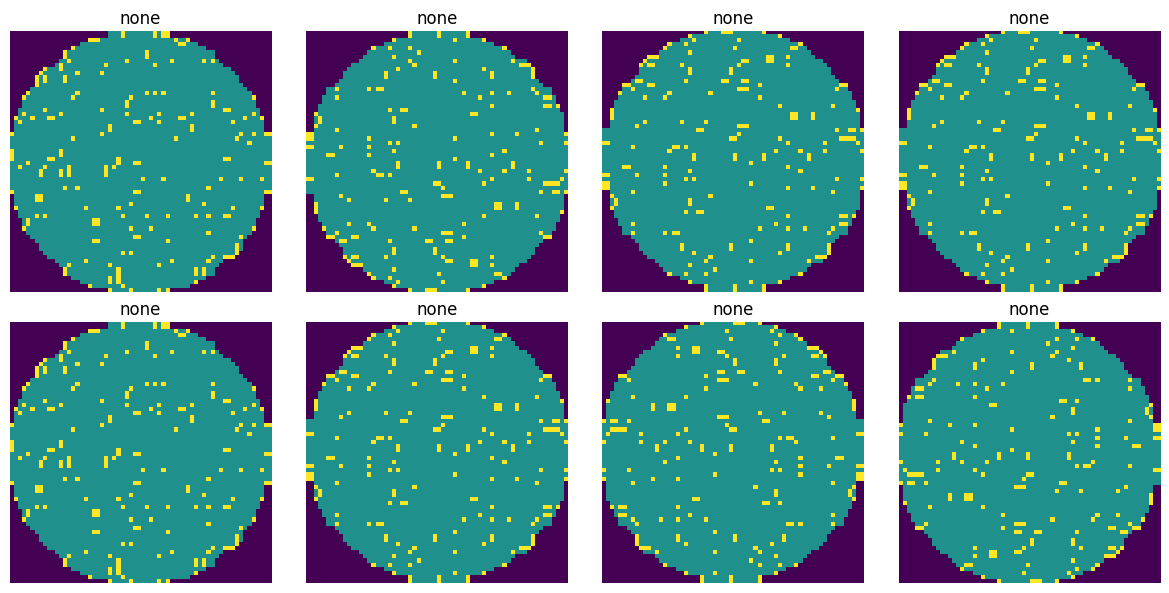

Unique values: tensor([0.0000, 0.5000, 1.0000])


In [57]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6)
)

for ax in axes.flat:

    image, label = aug_train_dataset[0]

    ax.imshow(
        image.squeeze(0),
        interpolation="nearest"
    )

    ax.set_title(
        class_names[label.item()]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()
image, label = aug_train_dataset[0]

print(
    "Unique values:",
    torch.unique(image)
)

In [61]:
augmented_model = SimpleCNN(
    num_classes=9
).to(device)
augmented_criterion = nn.CrossEntropyLoss(
    weight=sqrt_class_weights
)
augmented_optimizer = torch.optim.Adam(
    augmented_model.parameters(),
    lr=1e-3
)
AUG_MODEL_PATH = (
    MODEL_DIR
    / "tempered_aug_cnn_best.pt"
)

EPOCHS = 10

aug_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
    "val_balanced_acc": []
}

aug_best_macro_f1 = -1.0

In [62]:
for epoch in range(1, EPOCHS + 1):

    (
        train_loss,
        train_acc
    ) = train_one_epoch(
        augmented_model,
        aug_train_loader,
        augmented_criterion,
        augmented_optimizer,
        device
    )

    (
        val_loss,
        val_acc,
        y_true,
        y_pred
    ) = evaluate_model(
        augmented_model,
        aug_val_loader,
        augmented_criterion,
        device
    )

    val_macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    val_balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    aug_history["train_loss"].append(
        train_loss
    )

    aug_history["train_acc"].append(
        train_acc
    )

    aug_history["val_loss"].append(
        val_loss
    )

    aug_history["val_acc"].append(
        val_acc
    )

    aug_history["val_macro_f1"].append(
        val_macro_f1
    )

    aug_history["val_balanced_acc"].append(
        val_balanced_acc
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f} | "
        f"Macro-F1 {val_macro_f1:.4f} | "
        f"Balanced Acc {val_balanced_acc:.4f}"
    )

    # Validation Macro-F1 기준으로 저장
    if val_macro_f1 > aug_best_macro_f1:

        aug_best_macro_f1 = (
            val_macro_f1
        )

        torch.save(
            augmented_model.state_dict(),
            AUG_MODEL_PATH
        )

        print(
            "  → Best augmentation model saved"
        )

Epoch 01/10 | Train Loss 0.8369 | Train Acc 0.9031 | Val Loss 0.4754 | Val Acc 0.9446 | Macro-F1 0.6474 | Balanced Acc 0.7002
  → Best augmentation model saved
Epoch 02/10 | Train Loss 0.5476 | Train Acc 0.9238 | Val Loss 0.5696 | Val Acc 0.9487 | Macro-F1 0.6430 | Balanced Acc 0.6511
Epoch 03/10 | Train Loss 0.4784 | Train Acc 0.9315 | Val Loss 0.3608 | Val Acc 0.9555 | Macro-F1 0.6992 | Balanced Acc 0.7536
  → Best augmentation model saved
Epoch 04/10 | Train Loss 0.4448 | Train Acc 0.9344 | Val Loss 0.3695 | Val Acc 0.9379 | Macro-F1 0.6920 | Balanced Acc 0.7829
Epoch 05/10 | Train Loss 0.4221 | Train Acc 0.9359 | Val Loss 0.3137 | Val Acc 0.9586 | Macro-F1 0.7695 | Balanced Acc 0.7914
  → Best augmentation model saved
Epoch 06/10 | Train Loss 0.3995 | Train Acc 0.9387 | Val Loss 0.3371 | Val Acc 0.9626 | Macro-F1 0.7659 | Balanced Acc 0.7849
Epoch 07/10 | Train Loss 0.3815 | Train Acc 0.9407 | Val Loss 0.4363 | Val Acc 0.9643 | Macro-F1 0.7615 | Balanced Acc 0.7550
Epoch 08/10 | Tr

In [63]:
augmented_model.load_state_dict(
    torch.load(
        AUG_MODEL_PATH,
        map_location=device
    )
)

augmented_model.to(device)

print(
    "Best Validation Macro-F1:",
    aug_best_macro_f1
)

Best Validation Macro-F1: 0.7849711446489187


In [66]:
(
    aug_test_loss,
    aug_test_acc,
    aug_test_true,
    aug_test_pred
) = evaluate_model(
    augmented_model,
    aug_test_loader,
    augmented_criterion,
    device
)

aug_test_macro_f1 = f1_score(
    aug_test_true,
    aug_test_pred,
    average="macro"
)

aug_test_balanced_acc = (
    balanced_accuracy_score(
        aug_test_true,
        aug_test_pred
    )
)

print(
    "Augmented Test Accuracy:",
    round(aug_test_acc, 4)
)

print(
    "Augmented Test Balanced Accuracy:",
    round(aug_test_balanced_acc, 4)
)

print(
    "Augmented Test Macro-F1:",
    round(aug_test_macro_f1, 4)
)

comparison_4models = pd.DataFrame({
    "Model": [
        "Baseline",
        "Full Weighted",
        "Tempered",
        "Tempered + Aug"
    ],

    "Accuracy": [
        baseline_test_acc,
        weighted_test_acc,
        tempered_test_acc,
        aug_test_acc
    ],

    "Balanced Accuracy": [
        baseline_balanced_acc,
        weighted_balanced_acc,
        tempered_test_balanced_acc,
        aug_test_balanced_acc
    ],

    "Macro F1": [
        baseline_macro_f1,
        weighted_macro_f1,
        tempered_test_macro_f1,
        aug_test_macro_f1
    ]
})

display(
    comparison_4models
)
aug_recall = recall_score(
    aug_test_true,
    aug_test_pred,
    labels=np.arange(9),
    average=None
)

recall_comparison_4 = pd.DataFrame({
    "Class": class_names,

    "Baseline": baseline_recall,

    "Full Weighted":
        weighted_recall,

    "Tempered":
        tempered_recall,

    "Tempered + Aug":
        aug_recall
})

display(
    recall_comparison_4
)
# ============================================================
# DAY 7 SUMMARY
#
# Experiment:
# Tempered Class Weight + Train-only Augmentation
#
# Augmentation:
# - 90° rotation
# - Horizontal flip
# - Vertical flip
#
# Test Results
#
# Accuracy          : 0.9660
# Balanced Accuracy : 0.8133
# Macro-F1          : 0.7655
#
#
# Scratch Recall
#
# Baseline       : 0.0395
# Full Weighted  : 0.3446
# Tempered       : 0.1977
# Tempered + Aug : 0.3333
#
#
# 주요 결과:
#
# augmentation을 추가한 결과,
# Scratch 등 일부 minority defect의 Recall은 개선되었다.
#
# Balanced Accuracy:
# 0.7748 (Tempered)
# →
# 0.8133 (Tempered + Aug)
#
# 반면 Macro-F1:
# 0.7861
# →
# 0.7655
#
# 으로 감소하였다.
#
# Edge-Loc, Random 등 일부 클래스의 Recall 역시 감소했다.
#
# 해석:
#
# 회전/반전 augmentation은 일부 희귀 패턴의
# 일반화 성능을 개선했지만,
# 모든 wafer defect pattern에 동일하게 유효하지는 않았다.
#
# 방향 또는 위치 정보가 일부 클래스 구분에
# 유용했을 가능성이 있으며,
# augmentation으로 인해 해당 정보가 약화되었을
# 가능성이 있다.
#
#
# 현재 대표 모델:
#
# Tempered CNN
#
# Accuracy          : 0.9670
# Balanced Accuracy : 0.7748
# Macro-F1          : 0.7861
#
# 이유:
# 전체 Accuracy와 Macro-F1이 가장 높으면서
# Scratch / Loc 등 어려운 minority class의
# Recall도 Baseline 대비 개선했기 때문.
# ============================================================

Augmented Test Accuracy: 0.966
Augmented Test Balanced Accuracy: 0.8133
Augmented Test Macro-F1: 0.7655


,Model,Accuracy,Balanced Accuracy,Macro F1
0,Baseline,0.966273,0.785095,0.774534
1,Full Weighted,0.932972,0.835566,0.753416
2,Tempered,0.967008,0.774774,0.786140
3,Tempered + Aug,0.965964,0.813285,0.765485


,Class,Baseline,Full Weighted,Tempered,Tempered + Aug
0,none,0.988081,0.946343,0.989622,0.988534
1,Center,0.960199,0.953566,0.910448,0.932007
2,Donut,0.867470,0.975904,0.879518,0.903614
3,Edge-Loc,0.829016,0.853627,0.784974,0.750000
4,Edge-Ring,0.983240,0.966480,0.970670,0.968575
5,Loc,0.585069,0.592014,0.664931,0.647569
6,Random,0.946565,0.954198,0.908397,0.862595
7,Scratch,0.039548,0.344633,0.197740,0.333333
8,Near-full,0.866667,0.933333,0.666667,0.933333
